In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load Dataset
dataset = pd.read_csv("Salary_dataset.csv")
dataset.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [5]:
# Separate Features & Target
x = dataset[["YearsExperience"]]
y = dataset["Salary"]

In [6]:
# Train-Test Split
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42
)

In [7]:
# Create Linear Regression Model
model = LinearRegression()

In [8]:
# Train Model
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
#Predict Test Values
y_pred = model.predict(x_test)

In [12]:
# Display Prediction
prediction = pd.DataFrame({
    "Actual Salary" : y_test,
    "Predicted Salary" : y_pred
})
print(prediction)

    Actual Salary  Predicted Salary
27       112636.0     115791.210113
15        67939.0      71499.278095
23       113813.0     102597.868661
17        83089.0      75268.804224
8         64446.0      55478.792045
9         57190.0      60190.699707


In [19]:
# Predict New Salary
new_employee = pd.DataFrame({
    "YearsExperience":[2.3]
})

salary = model.predict(new_employee)

print("Predicted Salary =", salary[0])

Predicted Salary = 46054.976722444946


In [20]:
# CAlculate MEan Absolute Error
mae = mean_absolute_error(y_test,y_pred)
print("MAE =",mae)

MAE = 6286.453830757745


In [21]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("MSE =", mse)

MSE = 49830096.855908334


In [22]:
# calculate RMSE
rmse = np.sqrt(mse)
print("RMSE = ",rmse)

RMSE =  7059.043621901506


In [23]:
# CAlculate R2 Score
r2 = r2_score(y_test,y_pred)
print("R2 Score = ", r2)

R2 Score =  0.9024461774180498


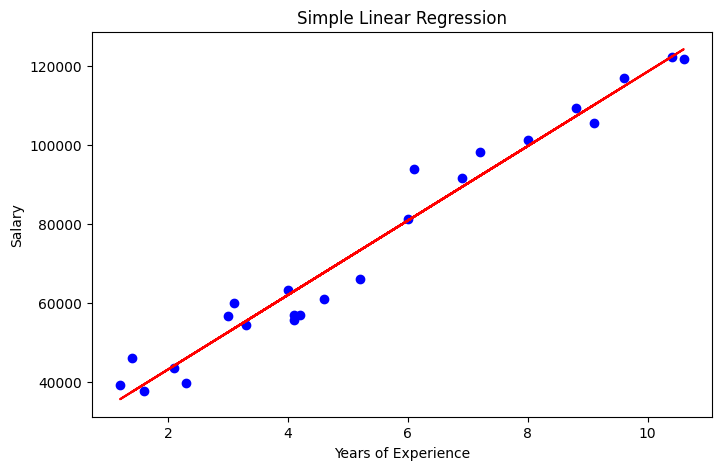

In [25]:
# Plot regresssion Line
plt.figure(figsize=(8,5))

plt.scatter(x_train, y_train, color="blue")

plt.plot(
    x_train,
    model.predict(x_train),
    color="red"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")

plt.show()

In [26]:
# Model Coefficient
print("Coefficient =", model.coef_[0])

Coefficient = 9423.81532303098


In [27]:
# Model Intercept
print("Intercept =", model.intercept_)

Intercept = 24380.20147947369


In [28]:
# Regression Equation
print("\nRegression Equation")

print(
    f"Salary = {model.intercept_:.2f} + ({model.coef_[0]:.2f} × YearsExperience)"
)


Regression Equation
Salary = 24380.20 + (9423.82 × YearsExperience)


In [29]:
# Residual Analysis
residuals = y_test - y_pred

residual_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals
})

print(residual_df)

      Actual      Predicted      Residual
27  112636.0  115791.210113  -3155.210113
15   67939.0   71499.278095  -3560.278095
23  113813.0  102597.868661  11215.131339
17   83089.0   75268.804224   7820.195776
8    64446.0   55478.792045   8967.207955
9    57190.0   60190.699707  -3000.699707


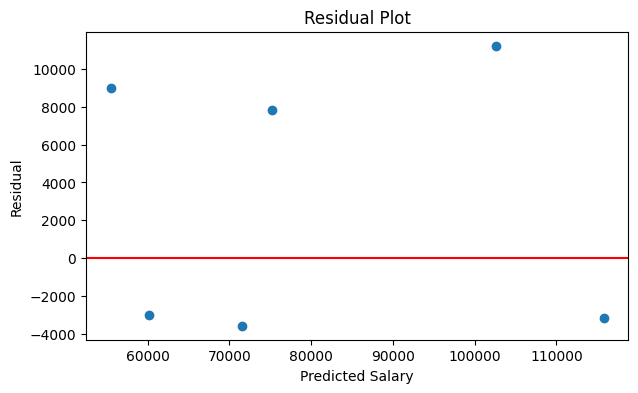

In [30]:
#PLot Residuals
plt.figure(figsize=(7,4))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Salary")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [31]:
# Predict Multiple New Employees
new_data = pd.DataFrame({
    "YearsExperience":[1,3,5,7,10]
})

prediction = model.predict(new_data)

result = new_data.copy()

result["Predicted Salary"] = prediction

print(result)

   YearsExperience  Predicted Salary
0                1      33804.016803
1                3      52651.647449
2                5      71499.278095
3                7      90346.908741
4               10     118618.354710
